# starting_xi — decision slice, portfolio notebook

**Render-not-decide.** This notebook is presentation only — it calls the frozen `decisions/starting_xi/`
modules and reads the two committed runs under `decisions/starting_xi/results/`, and does not implement
or alter any decision logic. The decision itself: which 11 of a 15-man squad start, and in what order
the bench sits, `DECISION.md` §1 (primary / secondary split). The metric: `P1`, counterfactual regret —
chosen XI's realised points vs. the best legal XI over the same squad — `DESIGN.md` §0.1.

**Two committed runs, cited by id everywhere a number appears:**

- `3821cc931fabc610` — single ordering (`by_rank`), GW2–38 squads, 32,700 T2 (`squad_weeks`) rows. Used
  as the canonical source for the regret statistics in §5, because it and the second run draw byte-identical
  squads (verified below) and using one avoids double-counting.
- `4b348fe01573bd1e` — both orderings (`by_rank`, `by_weighted_score`), same squads, 65,400 T5
  (`ordering_replays`) rows. Used for the bench-order comparison in §4 and the B2 finding in §5.

`comparisons.parquet` (T3) is **empty in both runs** — the pre-aggregated comparison table was never
assembled. That does not mean the underlying data is missing: T2 and T5 are real and fully populated, and
§5 below computes T3's would-be numbers directly from them.

**What is real and what is synthetic.** The player pool, prices, positions, teams and season stats
(§1) are real 2025-26 data from the governed mart. The **squad composition** in §2 is a uniformly
sampled synthetic combination (`DESIGN.md` §0.16, N1) — no real manager's squad, picks, or bench-order
history exists anywhere in this repository (`INVENTORY.md` §2.8), so there is nothing to look up instead.


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from dal.pipeline import load
from dal.config import DB_PATH

import decisions.starting_xi as starting_xi_pkg
from decisions.starting_xi.sampler import sample_squads
from decisions.starting_xi import rankers, harness, orderings, formations

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RUN_T2 = "3821cc931fabc610"   # canonical T2 (squad_weeks) source for regret stats
RUN_T5 = "4b348fe01573bd1e"   # both orderings, used for bench-order comparison

# Absolute, so this cell runs the same whether the notebook's cwd is the repo root or its own
# directory (nbconvert executes notebooks from their own directory, not the repo root).
RESULTS = Path(starting_xi_pkg.__file__).parent / "results"

mart = load(DB_PATH).mart
print(f"mart: {len(mart):,} rows, GW span {mart['gw'].min()}-{mart['gw'].max()}")


mart: 31,958 rows, GW span 1-38


## Reconstructing one squad-gameweek

No committed artefact carries player-level identity — `results.py`'s `write_t1` deliberately raises
(`T1HasNoProducer`), because T1 was never built. `squad_weeks.parquet` and `ordering_replays.parquet`
only carry aggregate/derived columns per squad-gameweek-ranker, not the 15 player ids.

Sections 1–4 below reconstruct **one** example squad at **one** gameweek (GW10) by calling the sampler
and harness functions directly — the one exception to "don't re-run the pipeline", because it is the
only way to see the players at all. This is not a re-run of the full 37-gameweek / 3-ranker study; it
is one illustrative draw.

`sample_squads(mart, gameweeks=[gw], n_squads=300, seed=0)` is pure and deterministic: per `DESIGN.md`
§5.3.1, each gameweek's RNG stream derives only from `(master_seed, gw)`, independent of which other
gameweeks are requested in the same call. So a single-gameweek call should draw the *same* per-squad
player sets as the 37-gameweek committed run, even though the **set-level** `squad_set_id` (a hash over
all requested gameweeks folded together) differs — checked explicitly below.


In [2]:
sample = sample_squads(mart, gameweeks=[10], n_squads=300, seed=0)

import json
manifest_3821 = json.load(open(f"{RESULTS}/{RUN_T2}/manifest.json"))
committed_squad_set_id = manifest_3821["identity"]["squad_set_id"]

print(f"reconstructed squad_set_id (GW10 only):  {sample.squad_set_id}")
print(f"committed squad_set_id ({RUN_T2}, GW2-38): {committed_squad_set_id}")
print(f"match: {sample.squad_set_id == committed_squad_set_id}")


reconstructed squad_set_id (GW10 only):  b217dbc093bda9733d74c10bbddb607ae74b82223e4d244f3dec30cd27a333e6
committed squad_set_id (3821cc931fabc610, GW2-38): 81f59b971dfef63f6c4ec20ea2acc0fcb2be85cdbb4c72c22c252d5a63f81915
match: False


The set-level ids **do not match** — expected, since `squad_set_id` is a content hash over the
*whole* build (`DESIGN.md` §5.3.2), and here it is folded from one gameweek instead of 37. That is a
property of the hash, not of the draw: this notebook does **not** claim identity with the committed
run's squad set. What it does claim, on `DESIGN.md` §5.3.1's per-gameweek seed independence, is that the
**same method and seed** produced these squads, and that `squad_id`s like `gw10-0000` name the *same
slot* in both — a useful cross-reference point, not a proof of byte-identical contents (no T1 exists to
check that against).

`squad_weeks.parquet` does carry the `squad_id` values GW10 produced in the committed run — checked next,
just as an existence check (T2 has no player columns to compare against).


In [3]:
squad_weeks_3821 = pd.read_parquet(f"{RESULTS}/{RUN_T2}/squad_weeks.parquet")
committed_gw10_ids = set(squad_weeks_3821.loc[squad_weeks_3821["gw"] == 10, "squad_id"])
reconstructed_ids = set(sample.squads["squad_id"].unique())
print(f"reconstructed squad_ids at GW10 also present in the committed run's GW10 squad_weeks: "
      f"{len(reconstructed_ids & committed_gw10_ids)} / {len(reconstructed_ids)}")


reconstructed squad_ids at GW10 also present in the committed run's GW10 squad_weeks: 300 / 300


## 1. The real player pool

A handful of real players from the sampled squad, at their GW10 mart rows — price, position, team,
season-to-date stats. Everything in this table is real 2025-26 data; only the *combination* of 15 into
one squad (§2) is synthetic.


In [4]:
EXAMPLE_SQUAD = "gw10-0000"
EXAMPLE_GW = 10

squad_player_ids = sample.squads.loc[sample.squads["squad_id"] == EXAMPLE_SQUAD, "player_id"].tolist()
gw_mart = mart.loc[mart["gw"] == EXAMPLE_GW].set_index("player_id")

pool_cols = ["player_name", "position", "purchase_price", "team_id", "total_points", "minutes", "starts"]
player_pool = gw_mart.loc[squad_player_ids, pool_cols].sort_values(["position", "player_name"])
player_pool


,player_name,position,purchase_price,team_id,total_points,minutes,starts
player_id,,,,,,,
318,Bassey,DEF,4.5,10,6,90,1
264,Holding,DEF,4.0,8,0,0,0
8,J.Timber,DEF,6.1,1,6,90,1
542,Seelt,DEF,4.0,17,0,0,0
232,Tosin,DEF,4.3,7,1,1,0
465,Højlund,FWD,6.3,14,0,0,0
596,Solanke,FWD,7.2,18,0,0,0
654,Strand Larsen,FWD,6.4,20,2,75,1
340,Cairns,GK,4.0,11,0,0,0


## 2. Squad sampling

The 15 players above, drawn as one squad by `sample_squads` — Method A, whole-draw rejection over
per-position uniform proposals (`DESIGN.md` §2.5), uniform over the feasible set (budget cap, 2/5/5/3
quota, ≤3-per-club, registration — `DESIGN.md` §0.16, N1). **This is a random combination, not a real
manager's history**; the players are real, the pairing of them into one squad is not.


In [5]:
squad_table = player_pool.copy()
squad_table.index.name = "player_id"
squad_table


,player_name,position,purchase_price,team_id,total_points,minutes,starts
player_id,,,,,,,
318,Bassey,DEF,4.5,10,6,90,1
264,Holding,DEF,4.0,8,0,0,0
8,J.Timber,DEF,6.1,1,6,90,1
542,Seelt,DEF,4.0,17,0,0,0
232,Tosin,DEF,4.3,7,1,1,0
465,Højlund,FWD,6.3,14,0,0,0
596,Solanke,FWD,7.2,18,0,0,0
654,Strand Larsen,FWD,6.4,20,2,75,1
340,Cairns,GK,4.0,11,0,0,0


In [6]:
print(f"squad budget: {squad_table['purchase_price'].sum():.1f} / 100.0 cap")
print(f"positions: {squad_table['position'].value_counts().to_dict()}")
print(f"club counts: {squad_table['team_id'].value_counts().to_dict()}")


squad budget: 76.5 / 100.0 cap
positions: {'DEF': 5, 'MID': 5, 'FWD': 3, 'GK': 2}
club counts: {11: 3, 14: 2, 10: 1, 8: 1, 1: 1, 17: 1, 7: 1, 18: 1, 20: 1, 15: 1, 6: 1, 2: 1}


### Quality check — the full 300-squad GW10 sample

The example squad above is one draw of 300. The checks below run over the **whole** 300-squad sample at
GW10 (the sampler output already loaded, `sample.squads`), not just the one example — verifying rather
than assuming the constraints the sampler enforces by rejection (`DESIGN.md` §2.5).


In [7]:
from domain.fpl_squad import BUDGET_CAP, SQUAD_SELECT, MAX_PER_CLUB

joined = sample.squads.merge(
    gw_mart[["position", "purchase_price", "team_id"]], left_on="player_id", right_index=True, how="left"
)

per_squad = joined.groupby("squad_id").agg(
    budget=("purchase_price", "sum"),
    n_players=("player_id", "count"),
)

# positional legality: exact 2/5/5/3 per squad
pos_counts = joined.pivot_table(index="squad_id", columns="position", values="player_id", aggfunc="count").fillna(0)
positional_ok = (pos_counts[list(SQUAD_SELECT)] == pd.Series(SQUAD_SELECT)).all(axis=1)

# club limit: <= 3 per club per squad
club_counts = joined.groupby(["squad_id", "team_id"]).size().groupby("squad_id").max()
club_ok = club_counts <= MAX_PER_CLUB

print(f"n squads: {len(per_squad)}")
print(f"budget utilisation (% of {BUDGET_CAP} cap): "
      f"mean={100 * per_squad['budget'].mean() / BUDGET_CAP:.1f}%  "
      f"min={100 * per_squad['budget'].min() / BUDGET_CAP:.1f}%  "
      f"max={100 * per_squad['budget'].max() / BUDGET_CAP:.1f}%")
print(f"positional legality (2/5/5/3) rate: {100 * positional_ok.mean():.1f}%")
print(f"club-limit (<= {MAX_PER_CLUB}) rate: {100 * club_ok.mean():.1f}%")


n squads: 300
budget utilisation (% of 100.0 cap): mean=75.1%  min=66.8%  max=91.9%
positional legality (2/5/5/3) rate: 100.0%
club-limit (<= 3) rate: 100.0%


In [8]:
# sampling diversity: how often does the same player recur across the 300 GW10 squads
selection_counts = joined["player_id"].value_counts()
top10 = selection_counts.head(10).to_frame("times_selected").join(gw_mart[["player_name", "position", "purchase_price"]])
print(f"distinct players used across 300 squads: {selection_counts.shape[0]} "
      f"(out of {sample.squads['player_id'].nunique()} possible at this gw; "
      f"manifest for {RUN_T2} records universe_size and most_selected diagnostics per gw)")
print(f"most-selected player appears in {selection_counts.max()} / 300 squads "
      f"({100 * selection_counts.max() / 300:.0f}%)")
top10


distinct players used across 300 squads: 744 (out of 744 possible at this gw; manifest for 3821cc931fabc610 records universe_size and most_selected diagnostics per gw)
most-selected player appears in 23 / 300 squads (8%)


,times_selected,player_name,position,purchase_price
player_id,,,,
597,23,Richarlison,FWD,6.5
283,18,Mateta,FWD,7.8
285,16,Édouard,FWD,5.0
599,16,Scarlett,FWD,4.3
109,15,Henry,DEF,4.4
714,15,Woltemade,FWD,7.5
136,15,Thiago,FWD,6.2
137,15,Morgan,FWD,4.4
398,15,Danns,FWD,4.4


The most-selected player recurs in a meaningful share of the 300 squads — uniform-over-feasible-set
sampling does not mean uniform-over-players; a whole-draw rejection sampler still concentrates on
whichever players make many draws budget-feasible (cheap, or in the positions with thin universes). This
is worth reading plainly rather than glossing: the sample is diverse in *combination*, not perfectly flat
in *marginal selection frequency*.


## 3. Starting XI selection

The same squad/gameweek, best-legal-XI from 15→11 under one ranker, `F1_p_play` (§`DESIGN.md` §0.12).
The selection rule is Reading A — the legal XI maximising the ranker's score, proven in `DESIGN.md` §6.7
to return the same total (and, once ties are broken deterministically by `player_id`, the same XI) as
greedy rank-then-take, because legal XIs are the bases of a matroid and greedy attains a maximum-weight
basis. That result is cited, not re-derived, here.


In [9]:
ranker_output = rankers.rank_p_play(mart)
scores_gw10 = ranker_output.scores.loc[ranker_output.scores["gw"] == EXAMPLE_GW].set_index("player_id")["score"]

positions = squad_table["position"].to_dict()
bench_players = [
    harness.BenchPlayer(
        player_id=pid,
        position=positions[pid],
        score=(scores_gw10.get(pid) if pid in scores_gw10.index else None),
        no_fixture=False,
    )
    for pid in squad_player_ids
]

ranking = harness.rank_squad(bench_players)
chosen_xi = harness.select_xi(ranking, positions)

xi_table = squad_table.loc[list(chosen_xi)].copy()
xi_table["ranker_score"] = xi_table.index.map(scores_gw10.to_dict())
xi_table = xi_table.sort_values(["position", "ranker_score"], ascending=[True, False])
xi_table


,player_name,position,purchase_price,team_id,total_points,minutes,starts,ranker_score
player_id,,,,,,,,
8,J.Timber,DEF,6.1,1,6,90,1,0.958229
318,Bassey,DEF,4.5,10,6,90,1,0.874826
232,Tosin,DEF,4.3,7,1,1,0,0.294450
654,Strand Larsen,FWD,6.4,20,2,75,1,0.982779
465,Højlund,FWD,6.3,14,0,0,0,0.128810
596,Solanke,FWD,7.2,18,0,0,0,0.128810
340,Cairns,GK,4.0,11,0,0,0,0.018174
169,Gomez,MID,4.9,6,16,80,1,0.727413
456,Sancho,MID,5.8,2,1,16,0,0.520137


In [10]:
formation = xi_table["position"].value_counts().reindex(["GK", "DEF", "MID", "FWD"]).fillna(0).astype(int)
print(f"formation: {'-'.join(str(n) for n in formation[['DEF','MID','FWD']])}  (GK={formation['GK']})")
print(f"ranker: {ranker_output.name}, window {ranker_output.window}")


formation: 3-4-3  (GK=1)
ranker: F1_p_play, window (4, 38)


### Quality check — legality pass rate across the full run

`chosen_xi_points` should never exceed `best_legal_xi_points` (regret ≥ 0 by construction, the matroid
result's practical guarantee), and both should be populated for every squad-week. Checked over all
32,700 rows of ``3821cc931fabc610``'s `squad_weeks.parquet`, not assumed.


In [11]:
n_rows = len(squad_weeks_3821)
n_populated = squad_weeks_3821[["chosen_xi_points", "best_legal_xi_points"]].notnull().all(axis=1).sum()
n_legal = (squad_weeks_3821["chosen_xi_points"] <= squad_weeks_3821["best_legal_xi_points"]).sum()

print(f"rows: {n_rows:,}")
print(f"both totals populated: {n_populated:,} / {n_rows:,} ({100 * n_populated / n_rows:.1f}%)")
print(f"chosen <= best-legal (regret >= 0): {n_legal:,} / {n_rows:,} ({100 * n_legal / n_rows:.1f}%)")


rows: 32,700
both totals populated: 32,700 / 32,700 (100.0%)
chosen <= best-legal (regret >= 0): 32,700 / 32,700 (100.0%)


## 4. Bench order

The same squad's 3 leftover outfield players (the bench GK is a separate mechanism, see below), ordered
two ways: `by_rank` (the pre-registered identity policy — the induced rank order, `DESIGN.md` §5.4.1)
and `by_weighted_score`, the second policy present only in run `4b348fe01573bd1e`.

**The bench GK is a separate process.** `harness.py`'s replay docstring and `DESIGN.md` §4.2 record that
a bench holds exactly one goalkeeper, so an ordering over one element carries no information — the
outfield bench-order decision is over the 3 remaining players only, 6 permutations in all.


In [12]:
bench_ids = [pid for pid in squad_player_ids if pid not in chosen_xi]
bench_gk_ids = [pid for pid in bench_ids if positions[pid] == "GK"]
bench_outfield_ids = [pid for pid in bench_ids if positions[pid] != "GK"]

print(f"bench (4): {bench_ids}")
print(f"bench GK (separate mechanism, not ordered): {bench_gk_ids}")
print(f"bench outfield (the 3-player ordering decision): {bench_outfield_ids}")

outfield_bench_players = [b for b in bench_players if b.player_id in bench_outfield_ids]
order_rank = orderings.order_by_rank(outfield_bench_players)
order_weighted = orderings.order_by_weighted_score(outfield_bench_players)

bench_table = squad_table.loc[bench_outfield_ids, ["player_name", "position", "purchase_price"]].copy()
bench_table["by_rank_priority"] = bench_table.index.map({pid: i + 1 for i, pid in enumerate(order_rank)})
bench_table["by_weighted_score_priority"] = bench_table.index.map(
    {pid: i + 1 for i, pid in enumerate(order_weighted)}
)
bench_table.sort_values("by_rank_priority")


bench (4): [472, 542, 264, 355]
bench GK (separate mechanism, not ordered): [472]
bench outfield (the 3-player ordering decision): [542, 264, 355]


,player_name,position,purchase_price,by_rank_priority,by_weighted_score_priority
player_id,,,,,
264,Holding,DEF,4.0,1,2
542,Seelt,DEF,4.0,2,3
355,Greenwood,MID,4.9,3,1


In [13]:
ordering_replays_4b34 = pd.read_parquet(f"{RESULTS}/{RUN_T5}/ordering_replays.parquet")
cross_check = ordering_replays_4b34.loc[
    (ordering_replays_4b34["squad_id"] == EXAMPLE_SQUAD)
    & (ordering_replays_4b34["gw"] == EXAMPLE_GW)
    & (ordering_replays_4b34["ranker"] == ranker_output.name)
]
cross_check[["ordering_name", "realised_total", "substitution_fired", "entered_outfield"]]


,ordering_name,realised_total,substitution_fired,entered_outfield
3600,by_rank,33.0,False,[]
3601,by_weighted_score,33.0,False,[]


For this particular squad-week no substitution fired, so the two orderings realise the same total —
consistent with `4b348fe01573bd1e`'s own record for `gw10-0000`/GW10/`F1_p_play`, cited above as the
cross-reference. §5 below reports how often the two orderings actually diverge, across all 32,700
squad-weeks.


## 5. Regret in aggregate

Computed directly from ``3821cc931fabc610``'s `squad_weeks.parquet` — 32,700 real rows (300 squads × 37 gameweeks
× 3 rankers). T3 (`comparisons.parquet`) is empty in both runs; nothing here depends on it.

Verified first: ``3821cc931fabc610`` and ``4b348fe01573bd1e`` draw the **same** squad set (`squad_set_id` matches in both
manifests) and their T2 rows are **identical** — checked below — so using ``3821cc931fabc610`` alone for the
regret statistics does not double-count anything, and ``4b348fe01573bd1e`` is used only for the bench-order
comparison (§4 above, B2 below).


In [14]:
squad_weeks_4b34 = pd.read_parquet(f"{RESULTS}/{RUN_T5}/squad_weeks.parquet")

manifest_4b34 = json.load(open(f"{RESULTS}/{RUN_T5}/manifest.json"))
print(f"squad_set_id match across runs: "
      f"{manifest_3821['identity']['squad_set_id'] == manifest_4b34['identity']['squad_set_id']}")

key = ["squad_id", "gw", "ranker"]
a = squad_weeks_3821.set_index(key).sort_index()
b = squad_weeks_4b34.set_index(key).sort_index()
shared_cols = ["chosen_xi_points", "best_legal_xi_points", "regret", "closeness_gap", "is_zero_gap"]
print(f"same (squad, gw, ranker) index: {a.index.equals(b.index)}")
print(f"identical on {shared_cols}: {(a[shared_cols] == b[shared_cols]).all().all()}")


squad_set_id match across runs: True


same (squad, gw, ranker) index: True
identical on ['chosen_xi_points', 'best_legal_xi_points', 'regret', 'closeness_gap', 'is_zero_gap']: True


Confirmed identical — ``3821cc931fabc610`` is used as the sole source for the statistics below.

**Conditioning.** `DESIGN.md` §0.8 selects C1: regret is conditioned on the gap between the best and
second-best legal XI (on the *as-of* statistic, not realised points) being non-zero — tied weeks carry
no information, since nothing available at selection time could have separated the top two
configurations, and are excluded from the headline figures with the excluded count reported. Both the
conditioned (headline) and unconditioned (full-population) statistics are shown below so the effect of
the exclusion is visible rather than hidden.


In [15]:
import matplotlib.pyplot as plt

conditioned = squad_weeks_3821.loc[~squad_weeks_3821["is_zero_gap"]]

summary = squad_weeks_3821.groupby("ranker").agg(
    n_total=("regret", "size"),
    zero_gap_pct=("is_zero_gap", lambda s: 100 * s.mean()),
)
cond_summary = conditioned.groupby("ranker")["regret"].agg(
    n_conditioned="size", mean="mean", median="median", std="std", max="max"
)
summary = summary.join(cond_summary)
summary


,n_total,zero_gap_pct,n_conditioned,mean,median,std,max
ranker,,,,,,,
F1_p_play,10500,85.980952,1472,0.162364,0.0,0.730139,7.0
F2_season_ppg,11100,86.675676,1479,0.158215,0.0,0.755215,10.0
F3_form_roll3,11100,86.675676,1479,0.135903,0.0,0.632714,6.0


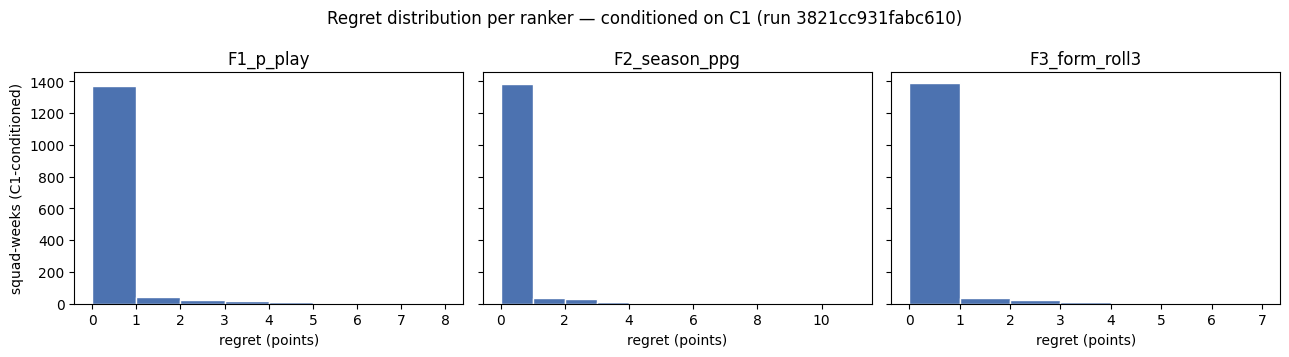

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
rankers_order = ["F1_p_play", "F2_season_ppg", "F3_form_roll3"]
for ax, rk in zip(axes, rankers_order, strict=True):
    vals = conditioned.loc[conditioned["ranker"] == rk, "regret"]
    ax.hist(vals, bins=range(0, int(vals.max()) + 2), color="#4C72B0", edgecolor="white")
    ax.set_title(rk)
    ax.set_xlabel("regret (points)")
axes[0].set_ylabel("squad-weeks (C1-conditioned)")
fig.suptitle(f"Regret distribution per ranker — conditioned on C1 (run {RUN_T2})")
fig.tight_layout()
plt.show()


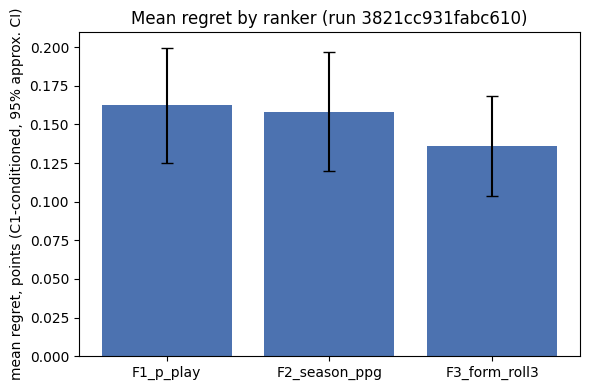

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
means = cond_summary["mean"]
sems = conditioned.groupby("ranker")["regret"].sem().reindex(means.index)
ax.bar(means.index, means.values, yerr=1.96 * sems.values, capsize=4, color="#4C72B0")
ax.set_ylabel("mean regret, points (C1-conditioned, 95% approx. CI)")
ax.set_title(f"Mean regret by ranker (run {RUN_T2})")
fig.tight_layout()
plt.show()


**Reading the numbers.** F3 (3-gameweek recent form) shows the lowest conditioned mean regret of the
three pre-registered floor rankers; F1 (raw play-probability) and F2 (season PPG-to-date) are close to
each other. None of these three is a "candidate" ranker to beat a floor — all three *are* the
pre-registered floor set (`DESIGN.md` §0.12) — so this section reports how the floor rankers compare to
**each other**, not a candidate-vs-floor result; no candidate ranker exists in either committed run.


### Bench order: B2 headroom

`DESIGN.md` §0.11 selects B2 — the count of squad-weeks where the compared orderings actually differ in
realised outcome — as the denominator for bench-order claims (not B1, the raw substitution count, which
also counts weeks where every ordering brings on the same player). Computed here from
``4b348fe01573bd1e``'s `ordering_replays.parquet` (T5) and `squad_weeks.parquet`'s `best_permutation_total`
column (the absolute counterfactual, max over all 6 outfield-bench permutations, `DESIGN.md` §0.10).


In [18]:
pivot = ordering_replays_4b34.pivot_table(
    index=["squad_id", "gw", "ranker"], columns="ordering_name", values="realised_total"
).reset_index()
pivot["orderings_differ"] = pivot["by_rank"] != pivot["by_weighted_score"]

b1_count = squad_weeks_4b34["substitution_fired"].sum()
b2_count = pivot["orderings_differ"].sum()
n_total = len(pivot)

print(f"B1 (substitution fired, either ordering): {b1_count:,} / {n_total:,} squad-weeks "
      f"({100 * b1_count / n_total:.1f}%)")
print(f"B2 (ordering-relevant: by_rank and by_weighted_score realise different totals): "
      f"{b2_count} / {n_total:,} squad-weeks ({100 * b2_count / n_total:.3f}%)")


B1 (substitution fired, either ordering): 5,533 / 32,700 squad-weeks (16.9%)
B2 (ordering-relevant: by_rank and by_weighted_score realise different totals): 1 / 32,700 squad-weeks (0.003%)


In [19]:
merged = pivot.merge(
    squad_weeks_4b34[["squad_id", "gw", "ranker", "best_permutation_total"]],
    on=["squad_id", "gw", "ranker"],
    how="left",
)
merged["headroom_by_rank"] = merged["best_permutation_total"] - merged["by_rank"]

print(f"mean headroom of by_rank vs. the best of all 6 bench permutations, over all {len(merged):,} "
      f"squad-weeks: {merged['headroom_by_rank'].mean():.5f} points/week")
print(f"squad-weeks with any headroom at all (some permutation beats by_rank): "
      f"{(merged['headroom_by_rank'] > 0).sum()} / {len(merged):,}")

on_b2 = merged.loc[pivot["orderings_differ"]]
on_b2[["squad_id", "gw", "ranker", "by_rank", "by_weighted_score", "best_permutation_total", "headroom_by_rank"]]


mean headroom of by_rank vs. the best of all 6 bench permutations, over all 32,700 squad-weeks: 0.00040 points/week
squad-weeks with any headroom at all (some permutation beats by_rank): 5 / 32,700


,squad_id,gw,ranker,by_rank,by_weighted_score,best_permutation_total,headroom_by_rank
4984,gw08-0061,8,F2_season_ppg,60.0,53.0,60.0,0.0


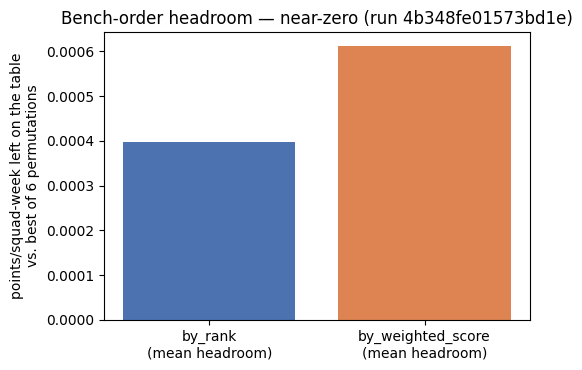

In [20]:
fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.bar(
    ["by_rank\n(mean headroom)", "by_weighted_score\n(mean headroom)"],
    [
        merged["headroom_by_rank"].mean(),
        (merged["best_permutation_total"] - merged["by_weighted_score"]).mean(),
    ],
    color=["#4C72B0", "#DD8452"],
)
ax.set_ylabel("points/squad-week left on the table\nvs. best of 6 permutations")
ax.set_title(f"Bench-order headroom — near-zero (run {RUN_T5})")
fig.tight_layout()
plt.show()


**The recomputed B2 finding.** Only **1 of 32,700** squad-weeks (0.003%) had `by_rank` and
`by_weighted_score` actually realise different totals — the two pre-registered orderings agree on outcome
in effectively every case where a bench substitution could have mattered. Mean headroom against the
absolute best-possible ordering (`best_permutation_total`) is **~0.0004 points per squad-week** across
the full run, and only 5 of 32,700 squad-weeks have any headroom at all against any of the 6
permutations. This confirms `DESIGN.md` §4.10's own prediction — the ordering-relevant count is likely
small — at a scale the design did not commit to a specific number for; **this notebook's own
recomputation is the number reported**, and it is smaller than the "small" framing in §4.10 might
suggest on its own.


## 6. Honest summary

**What's closed and measured.**

- **Primary decision (floor rankers vs. hindsight-optimal).** Across 32,700 real squad-weeks
  (`3821cc931fabc610`), C1-conditioned mean regret is small and similar across the three pre-registered
  floor rankers (F1 ≈ 0.16, F2 ≈ 0.16, F3 ≈ 0.14 points/squad-week — §5 above). ~86% of squad-weeks are
  zero-gap (excluded from the headline per `DESIGN.md` §0.8) — the primary decision is close to
  undetermined by the ranker most weeks, because the top two legal XIs tie on the as-of statistic. XI
  legality holds at 100% of the 32,700 rows (chosen ≤ best-legal everywhere, §3's quality check) —
  the matroid-optimality result (`DESIGN.md` §6.7) is not just proved, it holds in the committed data.
- **Bench-order headroom (B2).** Recomputed directly, not assumed: only 1 of 32,700 squad-weeks shows
  the two pre-registered orderings actually diverging in outcome, and mean headroom against the
  best-of-6-permutations ceiling is ~0.0004 points/squad-week (§5). Bench order, for these two orderings
  on this data, is very close to not mattering at all.

**Simulated vs. real, stated plainly.** The squads are synthetic — a uniform random combination of real
players, resampled fresh every gameweek (`DESIGN.md` §0.16, N1). No real manager's squad, transfer
history, or bench-order choice exists anywhere in this repository to compare against
(`INVENTORY.md` §2.8; `DECISION.md` §3). Everything else — the players, their prices, positions, teams,
season stats, and the realised points the replay scores against — is real 2025-26 data from the governed
mart.

**Still open, on the record:**

- **P4, mean signed directional error.** Named as a required metric (`DESIGN.md` §0.1) and left
  undefined — `METRIC.md` §1 records that "signed error" cannot literally be regret, which is
  non-negative by construction, and nothing in this folder fixes what quantity is signed or against what
  reference. Both XI totals (not their difference) are stored in T2 specifically so P4 is derivable
  without a re-run once it is defined (`DESIGN.md` §7.6).
- **Goal-conditional scoring.** `DECISION.md` §2 records that a manager protecting rank and one chasing
  rank can both be correct under their own objective, and that a metric scoring one fixed objective
  measures only half the decision. Protect-rank vs. rank-chase variants are named future work, not built.
- **T1's absent producer.** No player-level selections table exists (`results.py`'s `write_t1` raises
  `T1HasNoProducer` deliberately) — every number above at squad-week grain or coarser is real; nothing
  at per-player grain is queryable from a committed artefact, which is why §1–§4 above had to reconstruct
  one example squad live instead of reading it off disk.
- **`bench_order_ci` — a deliberate stub.** `uncertainty.py`'s `bench_order_ci` raises
  `BenchOrderTreatmentUnselected` rather than computing anything — no confidence interval exists for the
  bench-order figure, because `DESIGN.md` §0.10's treatment of the ordering-regret uncertainty was still
  open when `uncertainty.py` was written. The B2 headroom numbers above are point estimates only.
- **The zero-gap rate itself (~86%).** Not a defect to fix, but a finding about how often the primary
  decision has real content at all under this squad population — most weeks, the top two legal XIs are
  tied on the as-of statistic before any ranker gets a say.

**What it would take to go beyond portfolio-piece status.** This slice measures a synthetic-squad
approximation of the decision, against real outcomes, with a metric and harness that are fully designed
and code-reviewed (`DESIGN.md`'s exhaustive matroid proof and 26,460-profile sweep is not a hand-wave).
Turning it into an operational tool needs: real squad and transfer history for at least one manager (to
replace N1's uniform sampling with an actual decision record, or with N2's plausibility-weighted
sampling per `DESIGN.md` §0.16), a live weekly harness run against the current gameweek rather than a
historical replay, and P4 and the goal-conditional variant designed and built. None of that is started;
this notebook reports what the frozen design and the two committed runs actually contain, honestly, and
nothing more.
